# Overall trends across three groundtruth datasets 

In [1]:
import os
import pandas as pd
from collections import defaultdict
from tqdm import tqdm

from benchmarking.metrics.base_metrics import (
    compute_base_metrics,
    load_all_feature_tables,
)
from benchmarking.loader import get_upset_plot_data

from benchmarking.plots import (
    plot_individual_radars,
    plot_individual_upset,
    plot_intensity_distributions,
)

from benchmarking.loader import get_intensity_plot_data

##### Define datasets

In [2]:
base_dir_internal = "../data/groundtruth_dataset"
internal_datasets = [
    "MSV000098263",
    "NIST_SRM",
    "plant_spikein",
]

In [3]:
input_dataset_directories = []

for dataset in internal_datasets:
    input_dataset_directories.append(os.path.join(base_dir_internal, dataset))

len(input_dataset_directories)

3

# Calculating the metrics across tools

In [4]:
# Aggregate metrics across all datasets
combined_metrics = {}

for dataset_path in tqdm(input_dataset_directories):
    try:
        metrics = compute_base_metrics(
            dataset_path,
            similarity_threshold=0.7,
            annotation_subfolder="annotated_spectral_entropy",
        )

        for tool, tool_metrics in metrics.items():
            if tool not in combined_metrics:
                combined_metrics[tool] = defaultdict(int)

            for metric, value in tool_metrics.items():
                combined_metrics[tool][metric] += value

    except Exception as e:
        print(f"Error processing {dataset_path}: {e}")
        continue

100%|██████████| 3/3 [00:04<00:00,  1.58s/it]


# Creating the radar plots

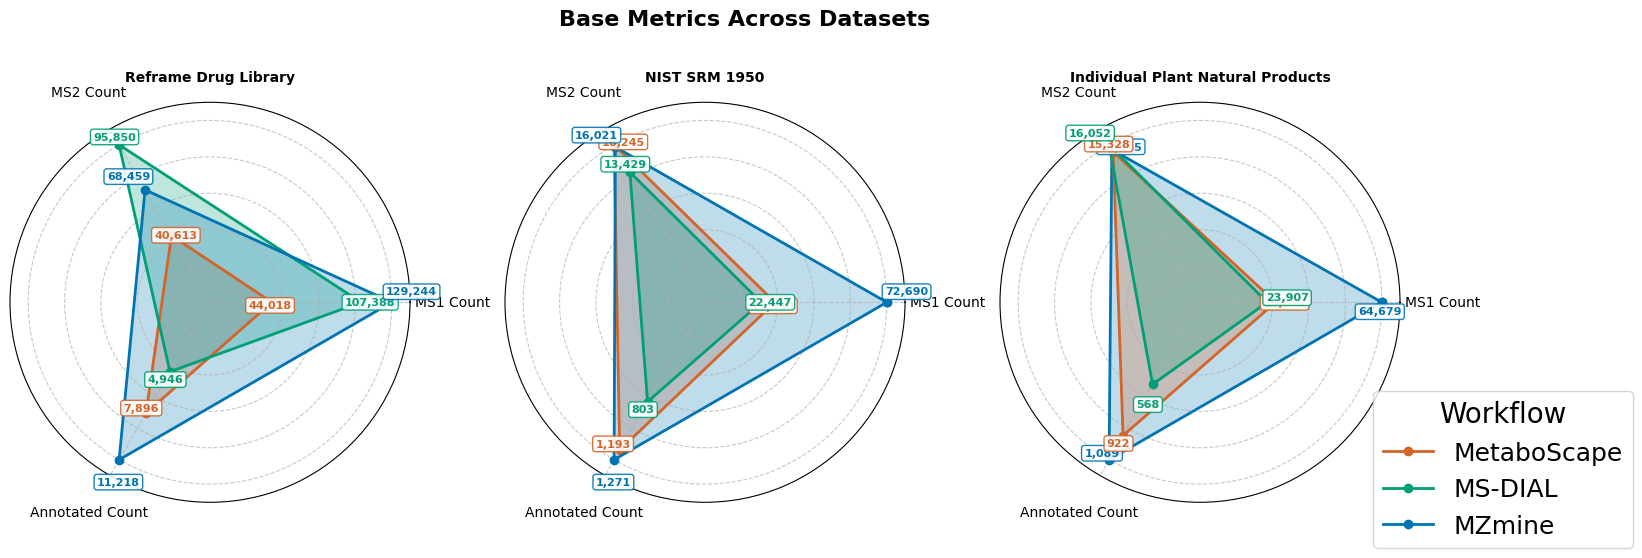

In [5]:
plot_individual_radars(
    input_dataset_directories,
    annotation_subfolder="annotated_spectral_entropy",
    title="Base Metrics Across Datasets",
    legend_position=(1.1, 0.1),
    grid_shape=(1, 3),
    save_path="../figures/supplementary_figure_7.png",
)

# Upset plots

In [6]:
plot_data = get_upset_plot_data(
    input_dataset_directories,
    similarity_threshold=0.7,
    annotation_subfolder="annotated_spectral_entropy",
)

Processing datasets: 100%|██████████| 3/3 [00:02<00:00,  1.18it/s]


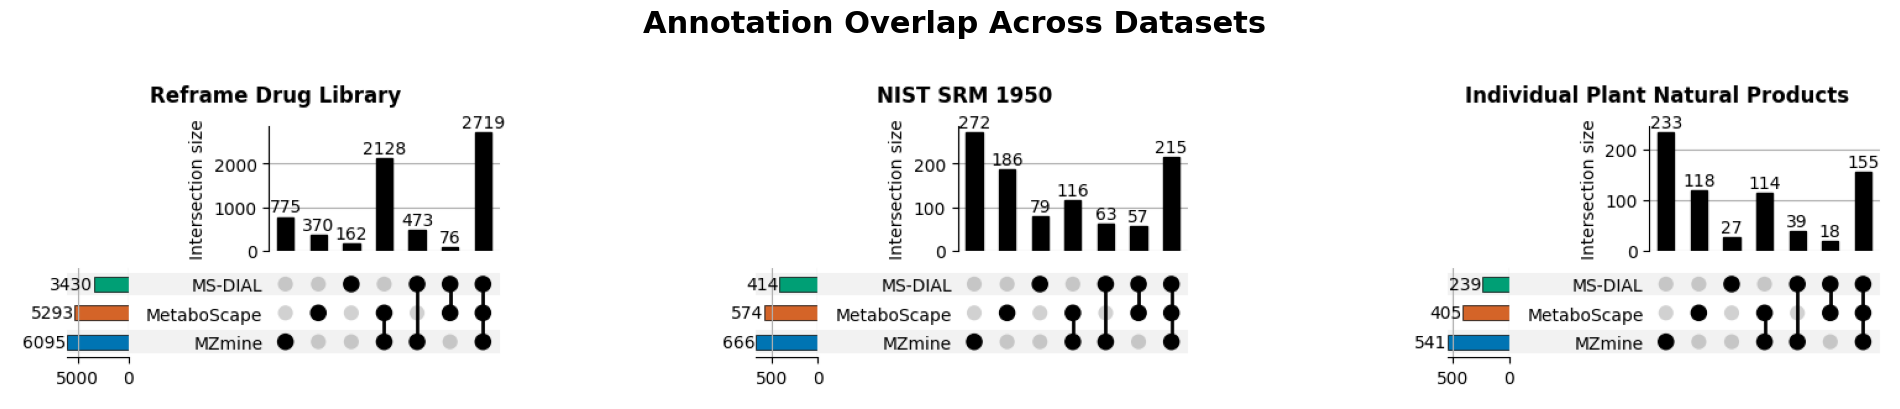

In [7]:
plot_individual_upset(
    input_dataset_directories,
    title="Annotation Overlap Across Datasets",
    similarity_threshold=0.7,
    # save_path=None,
    grid_shape=(1, 3),
)

# Intensity distribution with regards to true positives

In [8]:
reframe_ground_truth_library_data = pd.read_parquet(
    "../data/library_spectra/reframe_spikein_lib.pq"
)

nist_groundtruth_library_data = pd.read_parquet(
    "../data/library_spectra/nist_srm_spikein_lib.pq"
)

plant_spikein_library_data = pd.read_parquet(
    "../data/library_spectra/plant_spikein_lib.pq"
)

len(reframe_ground_truth_library_data), len(nist_groundtruth_library_data), len(
    plant_spikein_library_data
)

FileNotFoundError: [Errno 2] No such file or directory: '../data/library_spectra/nist_srm_spikein_lib.pq'

100%|██████████| 1/1 [00:03<00:00,  3.52s/it]


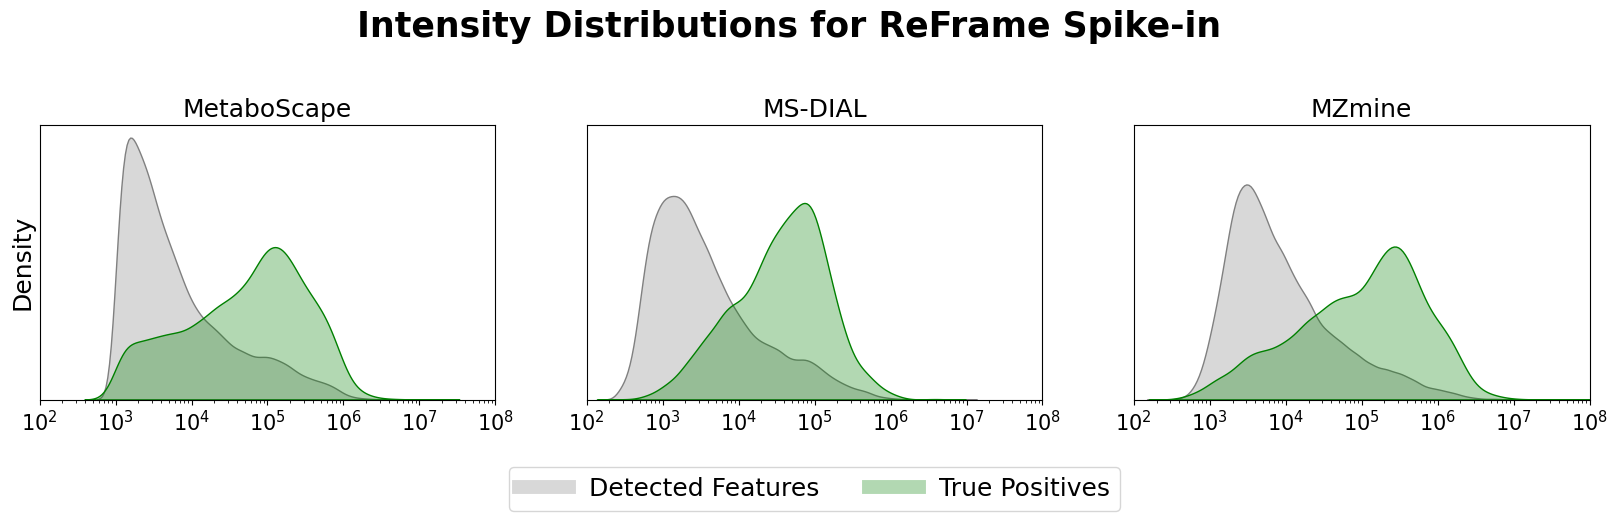

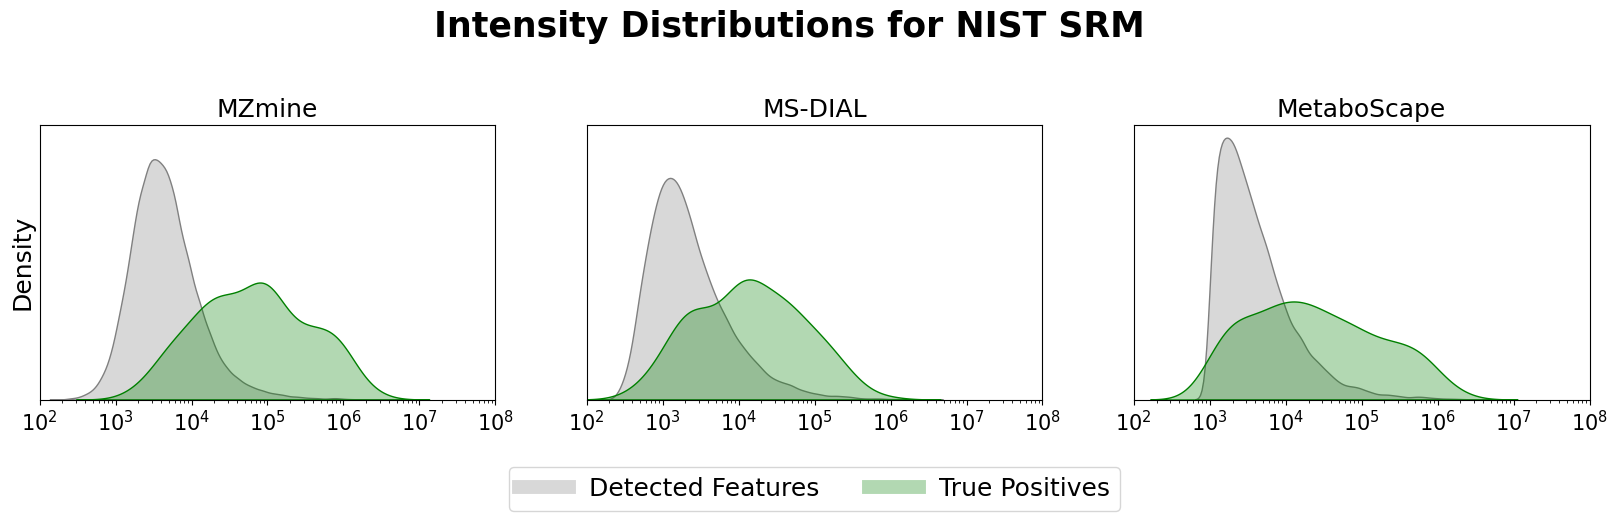

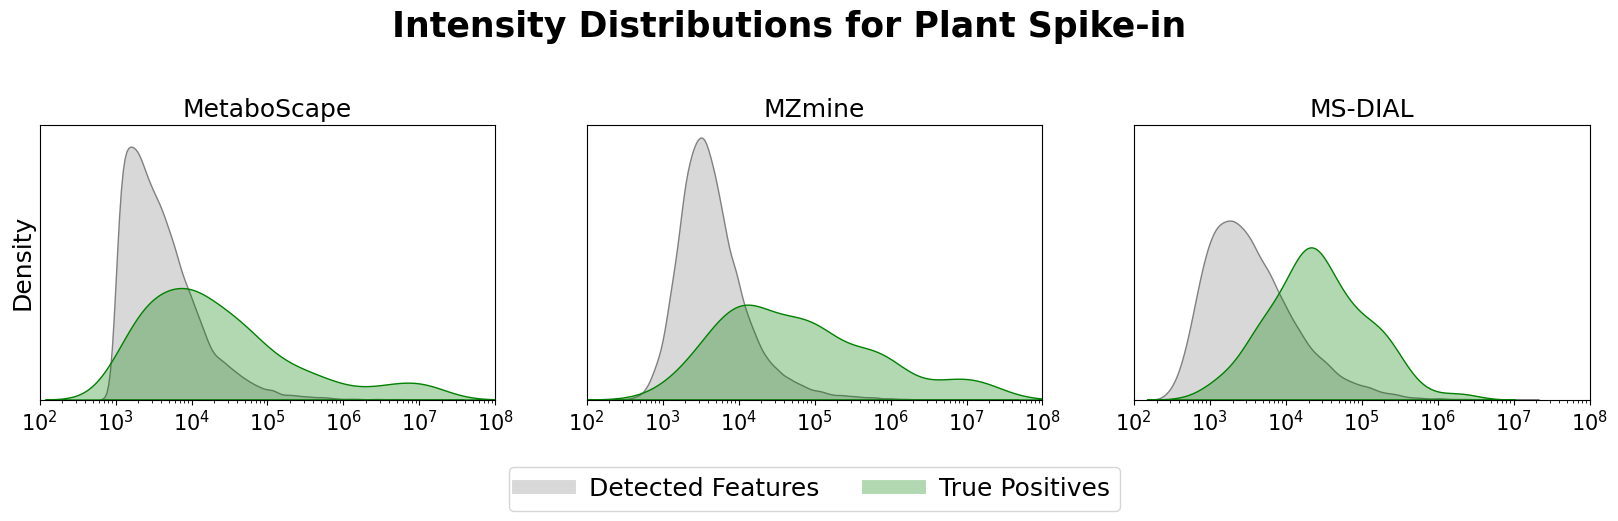

In [ ]:
for idx, (data_path, ground_truth_library_data, gt_name) in enumerate(
    zip(
        input_dataset_directories,
        [
            reframe_ground_truth_library_data,
            nist_groundtruth_library_data,
            plant_spikein_library_data,
        ],
        ["ReFrame Spike-in", "NIST SRM", "Plant Spike-in"],
    )
):
    merged_feature_tables = load_all_feature_tables(
        [data_path],
        annotation_subfolder="annotated_spectral_entropy",
    )

    intensity_plot_data = get_intensity_plot_data(
        ground_truth_library_data,
        merged_feature_tables=merged_feature_tables,
        score_threshold=0.7,
        score_method="spectral_entropy",
    )

    plot_intensity_distributions(
        intensity_plot_data,
        figsize=(20, 5),
        suptitle_fontsize=25,
        suptitle_fontweight="bold",
        suptitle_text=f"Intensity Distributions for {gt_name}",
        save_path=f"../figures/supplementary_figure_10{chr(97 + idx)}.png",
    )